In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ML Projects/Carbon Emission.csv")

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [ ]:
df.head(10)

In [ ]:
df.head(2)

In [ ]:
df.info()

In [ ]:
df.shape

In [ ]:
df.isnull().sum()

In [ ]:
# correcting the column names
df.columns = [
    'Body_Type', 'Sex', 'Diet', 'Shower_Frequency', 'Heating_Energy_Source',
    'Transport', 'Vehicle_Type', 'Social_Activity', 'Monthly_Grocery_Bill',
    'Air_Travel_Frequency', 'Vehicle_Monthly_Distance_Km', 'Waste_Bag_Size',
    'Waste_Bag_Weekly_Count', 'TV_PC_Daily_Hours', 'New_Clothes_Monthly',
    'Internet_Daily_Hours', 'Energy_Efficiency', 'Recycling', 'Cooking_With', 'Carbon_Emission'
]


In [ ]:
df.head(2)

In [ ]:
df['Vehicle_Type'].value_counts()

In [ ]:
null_percentage = (df.isnull().sum() / len(df)) * 100
null_percentage

In [ ]:
df['Vehicle_Type'] = df['Vehicle_Type'].fillna("walk/bicycle/publicvehicle")

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df.describe()

In [ ]:
y = df['Carbon_Emission']
df = df.drop(columns=['Carbon_Emission'],axis = 1)

In [ ]:
df.head()

In [ ]:
df['Recycling'].value_counts()

In [ ]:
def create_dummy_variables(df, column_name):
    unique_values = {item for sublist in df[column_name].unique() for item in eval(sublist)}

    for value in unique_values:
        df[value] = df[column_name].apply(lambda x: value in x)

    df = df.drop(columns=column_name)

    return df, unique_values

df, recycling_categories = create_dummy_variables(df, 'Recycling')
df, cooking_categories = create_dummy_variables(df, 'Cooking_With')

dummy_info = {
    "Recycling": recycling_categories,
    "Cooking_With": cooking_categories
}

with open("dummy_info.pkl", "wb") as file:
    pickle.dump(dummy_info, file)


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoders = {}

for col in ['Body_Type', 'Shower_Frequency', 'Social_Activity', 'Air_Travel_Frequency', 'Waste_Bag_Size', 'Energy_Efficiency']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

with open("label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

In [ ]:
df.head(2)

In [ ]:
# Apply one-hot encoding
df = pd.get_dummies(df, columns=["Sex", "Diet", "Heating_Energy_Source", "Transport", "Vehicle_Type"], drop_first=True)

dummy_columns = list(df.columns)

# Save the dummy column names for deployment
with open("dummy_columns.pkl", "wb") as file:
    pickle.dump(dummy_columns, file)

In [ ]:
df.info()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

X_scaled = pd.DataFrame(X_scaled, columns=df.columns)


In [ ]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [ ]:
X_scaled.head(2)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)

In [ ]:
X_train.shape, y_train.shape

In [ ]:
X_train.columns

In [ ]:
X_test.shape, y_test.shape

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'Ridge': Ridge(),
    'Lasso': Lasso()
}

# Training and Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"{name}:")

    print(f"  R² Score: {r2_score(y_test, y_pred):.4f}")
    # Calculate RMSE without the 'squared' argument, then take the square root.
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"  RMSE: {rmse:.4f}")
    mean_y = np.mean(y_train)
    relative_rmse = (rmse / mean_y) * 100
    print(f"  Relative RMSE: {relative_rmse:.4f}")
    print("-" * 30)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize model
rf = RandomForestRegressor(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best R² Score: 0.9063539405806065


In [ ]:
final_model = RandomForestRegressor(
    max_depth=20,
    min_samples_leaf=2,
    min_samples_split=2,
    n_estimators=300,
    random_state=42
)

final_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=20, min_samples_leaf=2, n_estimators=300,
                      random_state=42)

In [ ]:
y_pred = final_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'R² Score: {r2:.2f}')

MSE: 87354.13
R² Score: 0.92


In [ ]:
rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.2f}')
mean_y = np.mean(y_train)
relative_rmse = (rmse / mean_y) * 100
print(f'Relative_RMSE: {relative_rmse:.2f}')

RMSE: 295.56
Relative_RMSE: 13.06


In [ ]:
# To save the random forest model
# import joblib
# joblib.dump(final_model, 'final_rf_model.pkl')


In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor

xgb = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
lgbm = LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
rf = RandomForestRegressor(n_estimators=300, max_depth=20, min_samples_leaf=1, min_samples_split=2, random_state=42)

ensemble_model = VotingRegressor([('XGBoost', xgb), ('LightGBM', lgbm), ('RandomForest', rf)])
ensemble_model.fit(X_train, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 715
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 35
[LightGBM] [Info] Start training from score 2263.556125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


VotingRegressor(estimators=[('XGBoost',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_...
                                          max_delta_step=None, max_depth=6,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=200,
                                          n_jobs=None, num_parallel_tree=None,
                                          random_state=42, ...)),
                            ('LightGBM',
                             LGBMRegressor(max_depth=6, n_estimators=200,
                                           random_state=42)),
                            ('RandomForest',
                             RandomForestRegressor(max_depth=20,
                                                   n_estimators=300,
                                                   random_state=42))])

In [ ]:
y_pred = ensemble_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'R² Score: {r2:.2f}')


MSE: 29452.64
R² Score: 0.97


In [ ]:
rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.2f}')
mean_y = np.mean(y_train)
relative_rmse = (rmse / mean_y) * 100
print(f'Relative_RMSE: {relative_rmse:.2f}')

RMSE: 171.62
Relative_RMSE: 7.58


In [ ]:
# import joblib

# # Save the model
# joblib.dump(ensemble_model, 'ensemble_model.pkl')

# print("Model saved successfully as 'ensemble_model.pkl'")

In [ ]:
import pickle
with open('ensemble_model.pkl', 'wb') as file:
    pickle.dump(model, file)

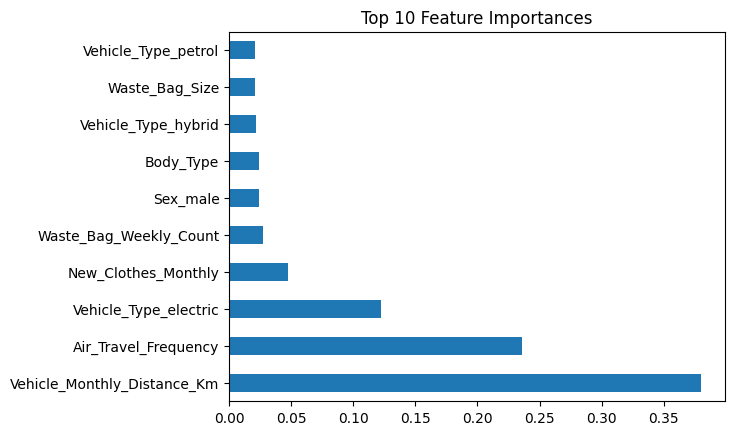

In [ ]:
feature_importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()